In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

In [53]:
import torch
from custom_vision_transformer import vit_custom
from training_utils import get_data_loaders
from types import SimpleNamespace
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from utils import *
from training_utils import val_one_epoch

In [54]:
params = SimpleNamespace(
    gpu_idx=1,
    num_classes=100,
    img_size=224,
    batch_size=16,
    bias_threshold=None,
    bias_topk=None
)

In [55]:
print("Number of visible GPUs :", torch.cuda.device_count())

torch.cuda.set_device(params.gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}:{torch.cuda.current_device()} {torch.cuda.get_device_name(torch.cuda.current_device())}" if torch.cuda.is_available() else "CPU")

Number of visible GPUs : 3
Device: cuda:1 NVIDIA RTX A4500


In [56]:
model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_threshold=params.bias_threshold, bias_topk=params.bias_topk).to(device)
checkpoint = torch.load("training_checkpoints/checkpoint6/vit_custom_epoch_200.pth")
checkpoint = checkpoint["model_state_dict"]
checkpoint = convert_qkv_to_q_k_v(checkpoint)
model.load_state_dict(checkpoint)
model.eval();

In [57]:
train_loader, val_loader = get_data_loaders(batch_size=params.batch_size, persistent_workers=False, shuffle_val=True)

imgs, labels = next(iter(val_loader))
tensor = imgs[0].unsqueeze(0).to(device)  # add batch dimension and move to device

In [58]:
avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
print(f"Validation Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

Validation Accuracy: 0.7932, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.0000


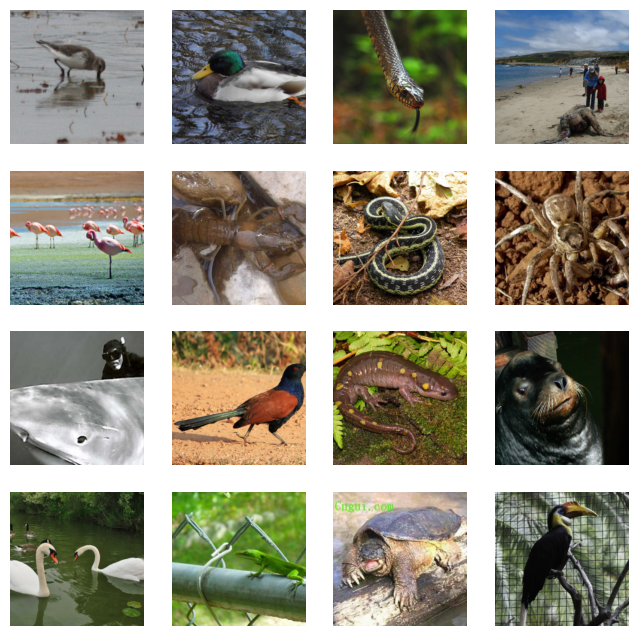

In [59]:
# display some images
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
sample_imgs = imgs[:16]  # take first 16 images
sample_imgs = sample_imgs.cpu().permute(0, 2, 3, 1) * torch.tensor(std).view(1, 1, 1, 3) + torch.tensor(mean).view(1, 1, 1, 3)
sample_imgs = torch.clamp(sample_imgs, 0, 1).numpy()
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    ax.axis('off')
plt.show()

In [ ]:
# Nettoyer les anciens hooks
for _, module in model.named_modules():
    if hasattr(module, '_forward_hooks'):
        module._forward_hooks.clear()

# Setup: créer les hooks pour extraire Q, K, QK, b
qk_by_layer = {}
b_by_layer = {}

def make_qk_b_hook(name):
    def hook(module, input, output):
        x = input[0]  # [B, T, C]
        B, T, _ = x.shape
        H, D = module.num_heads, module.head_dim

        # Extraire Q, K du qkv projection
        q = module.q(x).reshape(B, T, H, D).transpose(1, 2)  # (B, H, T, D)
        k = module.k(x).reshape(B, T, H, D).transpose(1, 2)  # (B, H, T, D)

        # Calculer QK logits
        qk = (q @ k.transpose(-2, -1)) * module.scale  # [B, H, T, T]
        qk_by_layer[name] = qk[0].cpu()

        # Extraire le biais b (si defini)
        if module.b is not None:
            b = module.b(x)  # [B, T, H]
            b = b.permute(0, 2, 1)  # [B, H, T]
            b_by_layer[name] = b[0].cpu()
        else:
            b_by_layer[name] = torch.zeros(module.num_heads, T)
    return hook

# Enregistrer les hooks sur tous les modules .attention
layer_names = []
for name, module in model.named_modules():
    if name.endswith(".attention"):
        module.register_forward_hook(make_qk_b_hook(name))
        layer_names.append(name)

# Forward pass pour remplir les dictionnaires
with torch.no_grad():
    _ = model(tensor.to(device))

# Trier les layer_names par index
layer_names = sorted(layer_names, key=lambda x: int(x.split('encoder_layer_')[1].split('.')[0]))

In [61]:
# Visualiser: QK, b, QK+b, softmax(QK+b), softmax(b)
output_dir = "attention_maps/attention_maps_raw"
os.makedirs(output_dir, exist_ok=True)

for layer_idx, name in enumerate(layer_names):
    qk = qk_by_layer[name]
    b = b_by_layer[name]
    n_heads = min(6, qk.shape[0], b.shape[0])

    fig, axes = plt.subplots(5, 6, figsize=(18, 15))
    fig.suptitle(f"Layer {layer_idx}: logits bruts et apres softmax", fontsize=14)

    for head in range(6):
        if head < n_heads:
            qk_h = qk[head]
            b_map = b[head].unsqueeze(0).repeat(qk_h.shape[0], 1)
            sum_map = qk_h + b_map

            amp = max(qk_h.abs().max().item(), b_map.abs().max().item(), sum_map.abs().max().item()) + 1e-12
            vmin, vmax = -amp, amp

            for ax, data, label in [(axes[0, head], qk_h, f"QK h{head}"),
                                     (axes[1, head], b_map, f"b h{head}"),
                                     (axes[2, head], sum_map, f"QK+b h{head}")]:
                ax.imshow(data.numpy(), cmap="RdBu_r", vmin=vmin, vmax=vmax)
                dmin, dmax = data.min().item(), data.max().item()
                ax.set_title(f"{label}\namp={amp:.2f} [{dmin:.2f},{dmax:.2f}]", fontsize=9)
                ax.axis("off")

            attn_with_b = torch.softmax(sum_map, dim=-1)
            axes[3, head].imshow(attn_with_b.numpy(), cmap="viridis", vmin=0.0, vmax=attn_with_b.max().item())
            axes[3, head].set_title(f"softmax(QK+b) h{head}\nmax={attn_with_b.max().item():.3f}", fontsize=9)
            axes[3, head].axis("off")

            attn_b = torch.softmax(b_map, dim=-1)
            axes[4, head].imshow(attn_b.numpy(), cmap="viridis", vmin=0.0, vmax=attn_b.max().item())
            axes[4, head].set_title(f"softmax(b) h{head}\nmax={attn_b.max().item():.3f}", fontsize=9)
            axes[4, head].axis("off")
        else:
            for row in range(5):
                axes[row, head].axis("off")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"{output_dir}/layer_{layer_idx}_qk_b_qkplusb_with_softmax.png")
    plt.close(fig)

In [62]:
print(qk_by_layer[layer_names[0]].shape)
print(b_by_layer[layer_names[0]].shape)

torch.Size([6, 197, 197])
torch.Size([6, 197])


In [63]:
# Scatter plots: b vs mean(QK), b vs mean(QK+b)
output_dir = "attention_maps/scatter_plots_raw"
os.makedirs(output_dir, exist_ok=True)

def safe_corr(x, y):
    x, y = np.asarray(x), np.asarray(y)
    return np.corrcoef(x, y)[0, 1] if x.std() > 1e-12 and y.std() > 1e-12 else np.nan

for layer_idx, name in enumerate(layer_names):
    qk = qk_by_layer[name]
    b = b_by_layer[name]
    n_heads = min(6, qk.shape[0], b.shape[0])

    fig, axes = plt.subplots(2, 6, figsize=(20, 7))
    fig.suptitle(f"Layer {layer_idx}: b vs logits", fontsize=14)

    for head in range(6):
        if head < n_heads:
            b_vec = b[head]
            qk_h = qk[head]
            y_qk = qk_h.mean(dim=0).numpy()
            y_qkpb = (qk_h + b_vec.unsqueeze(0)).mean(dim=0).numpy()

            b_np = b_vec.numpy()
            c1, c2 = safe_corr(b_np, y_qk), safe_corr(b_np, y_qkpb)

            # Ligne 1: b vs mean(QK)
            axes[0, head].scatter(b_np, y_qk, s=12, alpha=0.8)
            axes[0, head].set_title(f"h{head} QK (r={c1:.2f})", fontsize=9)
            axes[0, head].grid(True, alpha=0.3)
            axes[0, head].set_xlabel("b")
            axes[0, head].set_ylabel("mean(QK)")

            # Ligne 2: b vs mean(QK+b)
            axes[1, head].scatter(b_np, y_qkpb, s=12, alpha=0.8)
            axes[1, head].set_title(f"h{head} QK+b (r={c2:.2f})", fontsize=9)
            axes[1, head].grid(True, alpha=0.3)
            axes[1, head].set_xlabel("b")
            axes[1, head].set_ylabel("mean(QK+b)")
        else:
            axes[0, head].axis("off")
            axes[1, head].axis("off")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"{output_dir}/layer_{layer_idx}_scatter_b_qk.png")
    plt.close(fig)

In [ ]:
# Nombre moyen de colonnes telles que (biais < bias_threshold) par layer
bias_threshold = -1.0

avg_trunc_per_layer = [
    (b_by_layer[layer_names[l]] < bias_threshold).float().sum(dim=1).mean().item()
    for l in range(len(layer_names))
]

plt.figure(figsize=(8, 4))
plt.plot(avg_trunc_per_layer, marker="o")
plt.xlabel("Layer")
plt.ylabel(f"Nb moyen de colonnes telles que (biais < {bias_threshold})")
plt.title(f"Nombre moyen de colonnes telles que (biais < {bias_threshold}) par layer")
plt.xticks(range(len(avg_trunc_per_layer)))
plt.grid(True)
plt.tight_layout()
plt.savefig(f"attention_maps/avg_truncated_cols_per_layer_threshold_{bias_threshold}.png")
plt.close()

AttributeError: 'types.SimpleNamespace' object has no attribute 'threshold'